## Week6 lab Convolutional Neural Network
## Part 1: Install Required Libraries


In [1]:
!pip install torch torchvision matplotlib scikit-learn seaborn

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/dill-0.3.9-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_utilities-0.12.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/opt_einsum-3.4.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_thunder-0.2.0.dev0-py3.12.egg is deprecated. pip 25.1 wil

## Part 2: Import Packages

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

### Set Device

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Part 3: Load MNIST Dataset

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),                       # Converts image to tensor: [1, 28, 28]
    transforms.Normalize((0.1307,), (0.3081,))   # Standard MNIST normalization
])

train_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)

print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))

100%|██████████| 9.91M/9.91M [00:03<00:00, 2.59MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 117kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.11MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.17MB/s]


Training samples: 60000
Testing samples: 10000


### Visualize Sample Images

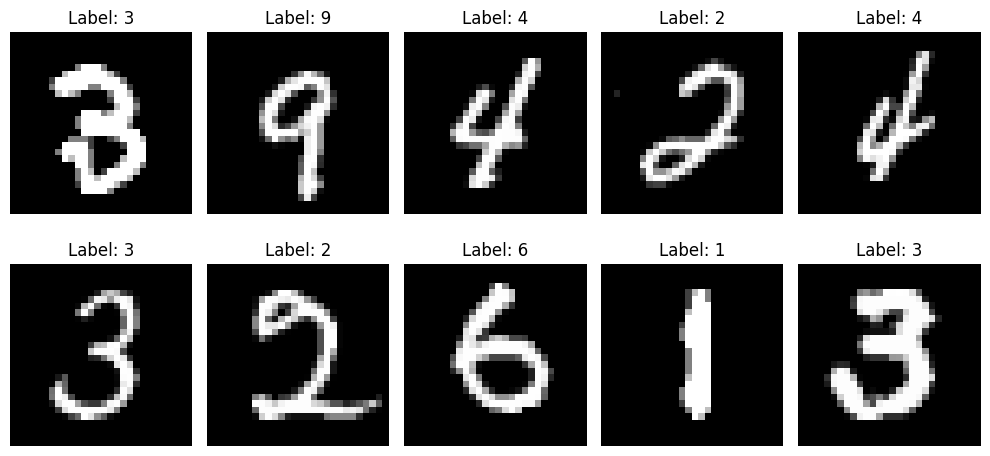

In [5]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Part 4: Define CNN Architecture

In [6]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # First convolutional layer
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            stride=1,
            padding=1
        )

        # Second convolutional layer
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=1
        )

        # Max pooling layer
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # Fully connected layers
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Some earlier labs may flatten MNIST to [batch_size, 784].
        # This line safely reshapes input back to [batch_size, 1, 28, 28].
        x = x.view(-1, 1, 28, 28)

        # First convolution block
        x = self.pool(F.relu(self.conv1(x)))

        # Second convolution block
        x = self.pool(F.relu(self.conv2(x)))

        # Flatten for fully connected layers
        x = x.view(-1, 64 * 7 * 7)

        # Dense layer
        x = F.relu(self.fc1(x))

        # Output logits
        x = self.fc2(x)

        return x

## Part 5: Initialize Model, Loss Function, and Optimizer


In [7]:
model_cnn = CNN().to(device)

criterion_cnn = nn.CrossEntropyLoss()
optimizer_cnn = optim.Adam(
    model_cnn.parameters(),
    lr=0.001
)

print(model_cnn)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## Part 6: Define Training Function

In [8]:
def train_cnn(model, dataloader, criterion, optimizer, epochs=5):
    model.train()

    epoch_losses = []

    for epoch in range(epochs):
        total_loss = 0.0

        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            # Ensure the input is 4D: [batch_size, 1, 28, 28]
            if images.ndimension() == 3:
                images = images.unsqueeze(1)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        epoch_losses.append(avg_loss)

        print(f"Epoch {epoch + 1}, Loss: {avg_loss:.4f}")

    return epoch_losses

## Part 7: Define Evaluation Function

In [9]:
def evaluate_cnn(model, dataloader):
    model.eval()

    correct = 0
    total = 0

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            # Ensure the input is 4D: [batch_size, 1, 28, 28]
            if images.ndimension() == 3:
                images = images.unsqueeze(1)

            outputs = model(images)

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total

    print(f"Accuracy: {accuracy:.4f}")

    return accuracy, all_predictions, all_labels

## Part 8: Run Training and Evaluation

In [10]:
print("Training CNN...")

loss_history = train_cnn(
    model=model_cnn,
    dataloader=train_loader,
    criterion=criterion_cnn,
    optimizer=optimizer_cnn,
    epochs=5
)

print("\nEvaluating CNN...")

accuracy, predictions, true_labels = evaluate_cnn(
    model=model_cnn,
    dataloader=test_loader
)

Training CNN...
Epoch 1, Loss: 0.1395
Epoch 2, Loss: 0.0434
Epoch 3, Loss: 0.0290
Epoch 4, Loss: 0.0217
Epoch 5, Loss: 0.0162

Evaluating CNN...
Accuracy: 0.9907


## Part 9: Plot Training Loss

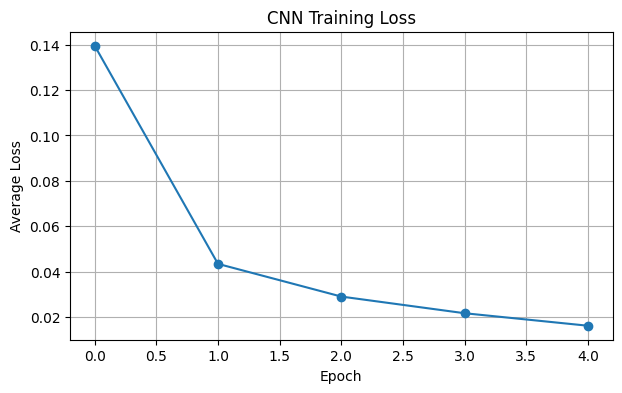

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history, marker="o")
plt.title("CNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.grid(True)
plt.show()

## Part 10: Classification Report and Confusion Matrix

In [12]:
print("Classification Report:")
print(
    classification_report(
        true_labels,
        predictions,
        digits=4
    )
)

Classification Report:
              precision    recall  f1-score   support

           0     0.9879    0.9980    0.9929       980
           1     0.9965    0.9991    0.9978      1135
           2     0.9932    0.9913    0.9922      1032
           3     0.9941    0.9960    0.9951      1010
           4     0.9858    0.9929    0.9893       982
           5     0.9943    0.9832    0.9887       892
           6     0.9855    0.9927    0.9891       958
           7     0.9836    0.9942    0.9889      1028
           8     0.9958    0.9784    0.9871       974
           9     0.9900    0.9792    0.9846      1009

    accuracy                         0.9907     10000
   macro avg     0.9907    0.9905    0.9906     10000
weighted avg     0.9907    0.9907    0.9907     10000



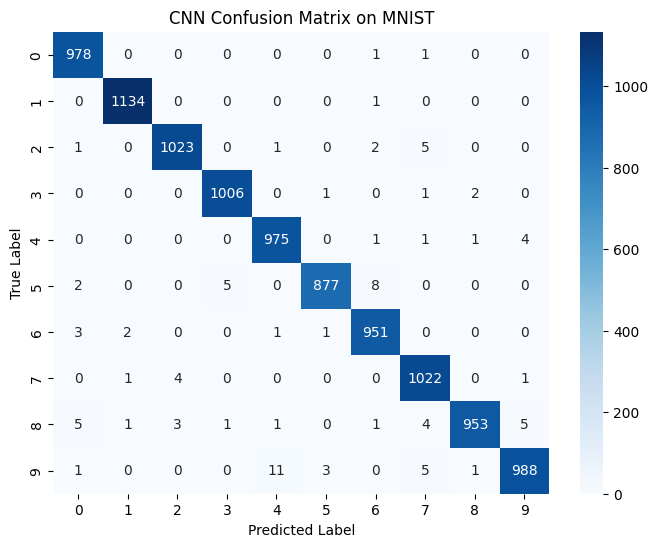

In [13]:
cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("CNN Confusion Matrix on MNIST")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Part 11: Inspect Predictions

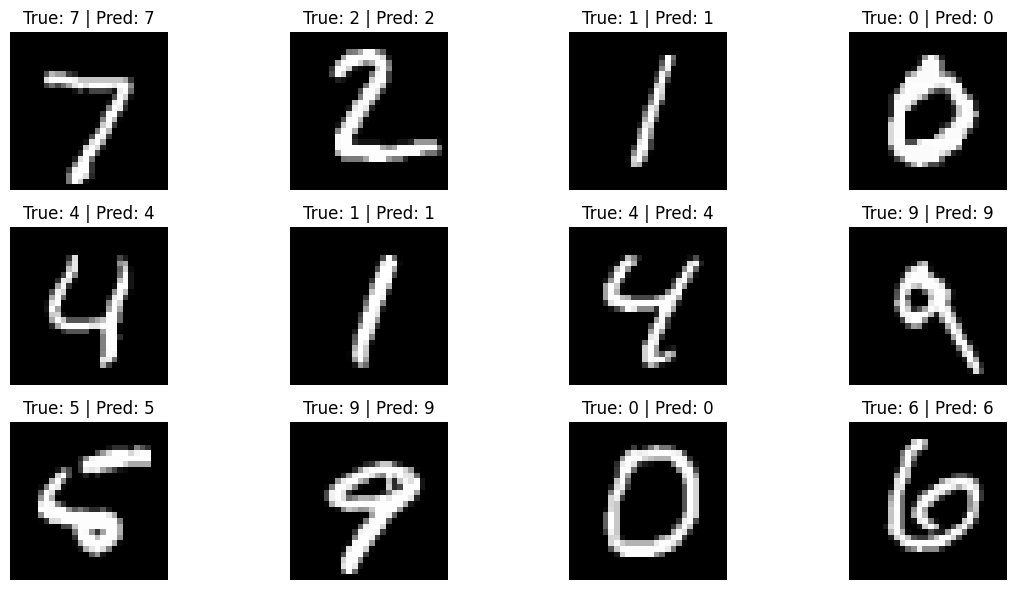

In [14]:
images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model_cnn(images)
_, preds = torch.max(outputs, 1)

images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"True: {labels[i].item()} | Pred: {preds[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Part 12: Visualize First Convolutional Layer Filters

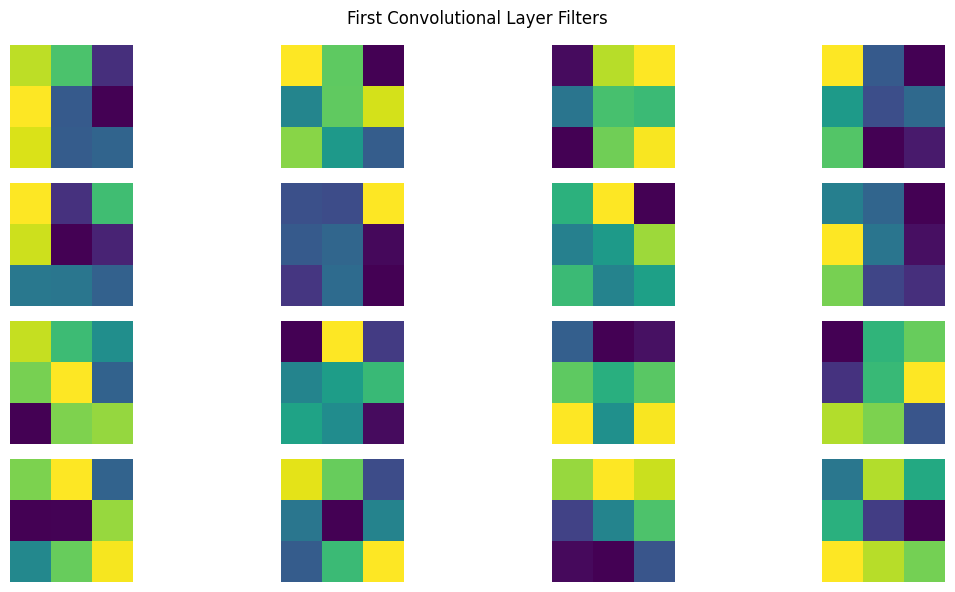

In [15]:
# Visualize filters from the first convolutional layer.
filters = model_cnn.conv1.weight.detach().cpu()

plt.figure(figsize=(12, 6))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(filters[i, 0], cmap="viridis")
    plt.axis("off")

plt.suptitle("First Convolutional Layer Filters")
plt.tight_layout()
plt.show()

## Part 13: Save the Model

In [16]:
torch.save(
    {
        "model_state_dict": model_cnn.state_dict(),
        "optimizer_state_dict": optimizer_cnn.state_dict(),
        "accuracy": accuracy,
        "loss_history": loss_history,
    },
    "lecture6_lab4_pytorch_cnn_mnist.pt"
)

print("Model saved as lecture6_lab4_pytorch_cnn_mnist.pt")

Model saved as lecture6_lab4_pytorch_cnn_mnist.pt


## Part 14: Optional Experiments

In [17]:
# Optional experiment ideas:
# 1. Change learning rate from 0.001 to 0.0005 or 0.01.
# 2. Add Dropout before fc1.
# 3. Add BatchNorm2d after convolutional layers.
# 4. Increase epochs from 5 to 10.
# 5. Compare Adam with SGD.
# 6. Compare this CNN with the FNN from Lab 1.

class CNNWithDropout(nn.Module):
    def __init__(self):
        super(CNNWithDropout, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, 1, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1, 1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 1, 28, 28)
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x